In [1]:
from pathlib import Path
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
CSV_DIR = Path("csv")
OUT_DIR = Path("paper_figures")
OUT_DIR.mkdir(exist_ok=True)

# Rename W&B run names to paper labels.
# Your PPO run appears as "skilled-sweep-15" in the CSV export.
ALG_RENAME = {
    "dqn": "DQN",
    "td3": "TD3",
    "sac": "SAC",
    "a2c": "A2C",
    "ppo": "PPO",
    "skilled-sweep-15": "PPO",
}

ALG_ORDER = ["DQN", "TD3", "SAC", "A2C", "PPO"]

# No extra smoothing by default because train/reward_mean and train/success_rate
# are already rolling metrics from the training callback.
EXTRA_ROLLING_WINDOW = 1

In [3]:
def canonical_algorithm(raw_name: str) -> str:
    raw = raw_name.strip()
    return ALG_RENAME.get(raw.lower(), raw.upper())


def detect_metric_columns(df: pd.DataFrame):
    """
    Find columns like:
        "dqn - train/reward_mean"
        "td3 - train/success_rate"

    Ignores W&B export helper columns:
        __MIN, __MAX, _step
    """
    detected = []

    for col in df.columns:
        if "__MIN" in col or "__MAX" in col or col.endswith("_step") or " - _step" in col:
            continue

        match = re.match(r"(.+?)\s+-\s+train/(reward_mean|success_rate)$", col)
        if match:
            raw_alg = match.group(1).strip()
            metric = match.group(2).strip()
            detected.append((col, canonical_algorithm(raw_alg), metric))

    return detected


def load_wandb_csv_exports(csv_dir: Path) -> pd.DataFrame:
    rows = []

    for path in sorted(csv_dir.glob("*.csv")):
        df = pd.read_csv(path)

        if "train/episode" in df.columns:
            x_col = "train/episode"
        elif "Step" in df.columns:
            x_col = "Step"
        else:
            print(f"Skipping {path.name}: no Step or train/episode column.")
            continue

        detected = detect_metric_columns(df)

        if not detected:
            print(f"Skipping {path.name}: no recognized train metric column.")
            continue

        for y_col, alg, metric in detected:
            tmp = df[[x_col, y_col]].copy()
            tmp.columns = ["episode", "value"]
            tmp["algorithm"] = alg
            tmp["metric"] = metric
            tmp["source_file"] = path.name

            tmp["episode"] = pd.to_numeric(tmp["episode"], errors="coerce")
            tmp["value"] = pd.to_numeric(tmp["value"], errors="coerce")
            tmp = tmp.dropna(subset=["episode", "value"])

            rows.append(tmp)

    if not rows:
        raise RuntimeError(f"No valid W&B CSV exports found in {csv_dir.resolve()}")

    data = pd.concat(rows, ignore_index=True)
    data["episode"] = data["episode"].astype(int)

    return data


data = load_wandb_csv_exports(CSV_DIR)

print("Detected data:")
display(
    data.groupby(["algorithm", "metric"])["episode"]
    .agg(["min", "max", "count"])
    .reset_index()
)

Detected data:


,algorithm,metric,min,max,count
0,A2C,reward_mean,1,2000,2000
1,A2C,success_rate,1,2000,2000
2,DQN,reward_mean,1,2000,2000
3,DQN,success_rate,1,2000,2000
4,PPO,reward_mean,1,2000,2000
5,PPO,success_rate,1,2000,2000
6,SAC,reward_mean,1,2000,2000
7,SAC,success_rate,1,2000,2000
8,TD3,reward_mean,1,2000,2000
9,TD3,success_rate,1,2000,2000


In [4]:
def aggregate_for_plot(data: pd.DataFrame) -> pd.DataFrame:
    """
    If there are duplicate rows for the same algorithm/metric/episode,
    average them. This makes the code safe if you later add multi-seed exports.
    """
    agg = (
        data.groupby(["algorithm", "metric", "episode"], as_index=False)
        .agg(value=("value", "mean"))
    )

    if EXTRA_ROLLING_WINDOW > 1:
        agg = agg.sort_values(["algorithm", "metric", "episode"])
        agg["value"] = (
            agg.groupby(["algorithm", "metric"])["value"]
            .transform(lambda s: s.rolling(EXTRA_ROLLING_WINDOW, min_periods=1).mean())
        )

    return agg


plot_data = aggregate_for_plot(data)

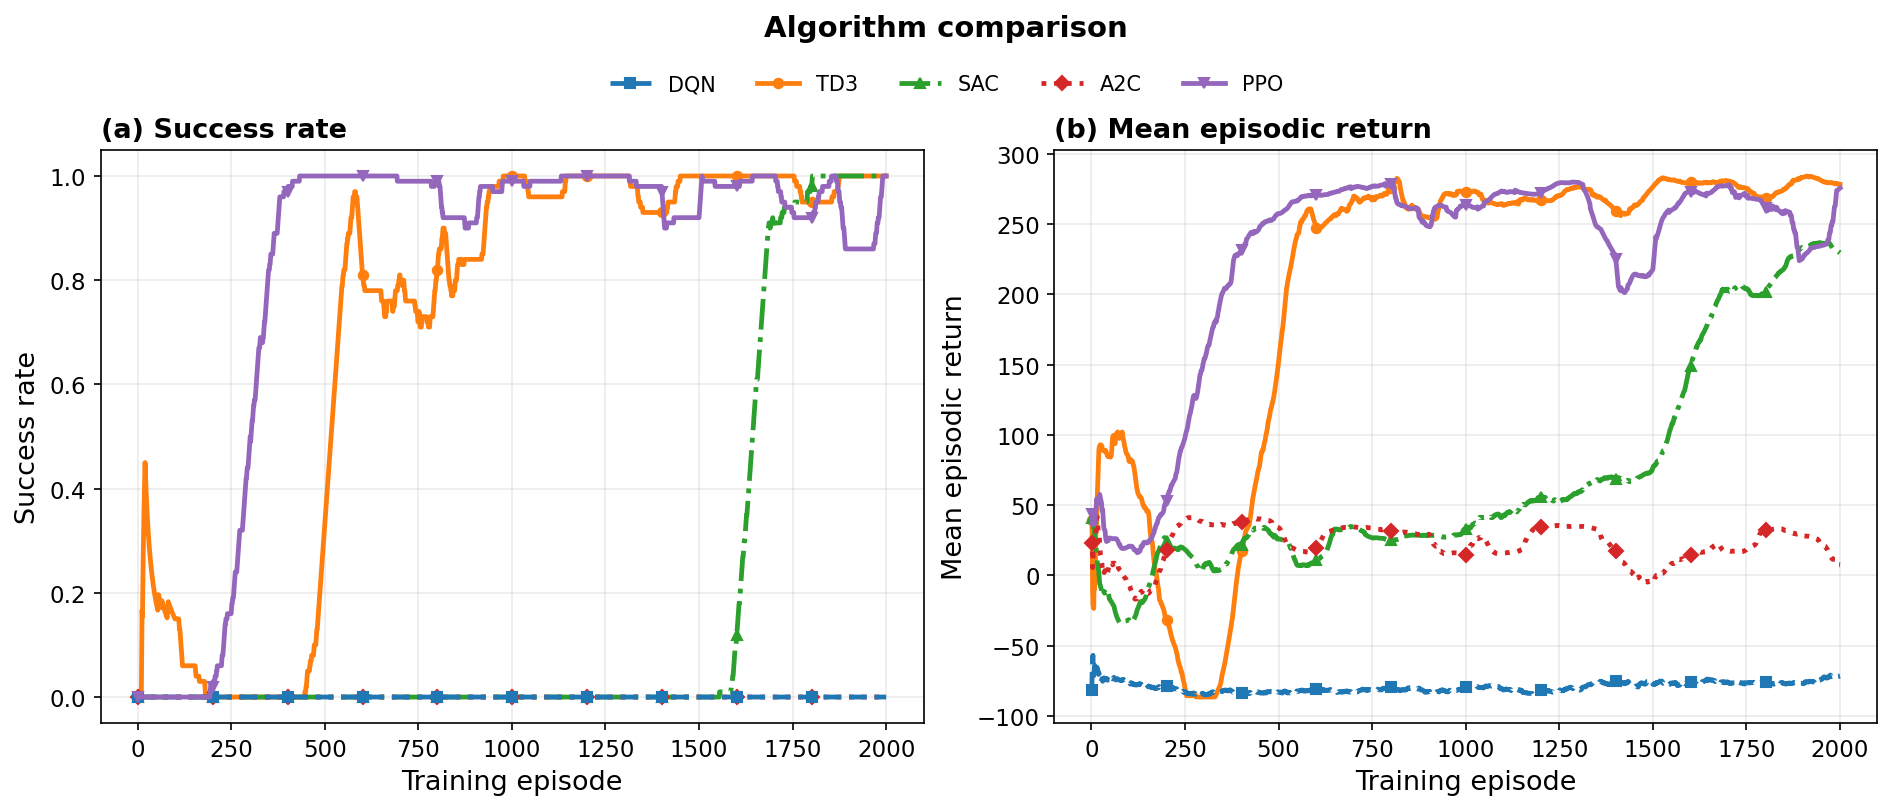

In [5]:
# Publication-style defaults
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "lines.linewidth": 2.3,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Line styles help distinguish methods even in grayscale.
LINE_STYLES = {
    "DQN": {"linestyle": "--", "marker": "s", "markevery": 200, "markersize": 4.5, "zorder": 5},
    "TD3": {"linestyle": "-",  "marker": "o", "markevery": 200, "markersize": 4.5, "zorder": 4},
    "SAC": {"linestyle": "-.", "marker": "^", "markevery": 200, "markersize": 4.5, "zorder": 4},
    "A2C": {"linestyle": ":",  "marker": "D", "markevery": 200, "markersize": 4.5, "zorder": 4},
    "PPO": {"linestyle": "-",  "marker": "v", "markevery": 200, "markersize": 4.5, "zorder": 6},
}


def plot_metric(ax, metric_name, ylabel, panel_label):
    metric_df = plot_data[plot_data["metric"] == metric_name].copy()

    for alg in ALG_ORDER:
        alg_df = metric_df[metric_df["algorithm"] == alg].sort_values("episode")
        if alg_df.empty:
            continue

        style = LINE_STYLES.get(alg, {})
        ax.plot(
            alg_df["episode"],
            alg_df["value"],
            label=alg,
            **style
        )

    ax.set_xlabel("Training episode")
    ax.set_ylabel(ylabel)
    ax.set_title(panel_label, loc="left", fontweight="bold")
    ax.tick_params(axis="both", which="major")

    # Keeps zero-valued DQN success curves visible above the axis line.
    if metric_name == "success_rate":
        ax.set_ylim(-0.05, 1.05)
        ax.set_yticks(np.linspace(0, 1, 6))


fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), constrained_layout=True)

plot_metric(
    axes[0],
    metric_name="success_rate",
    ylabel="Success rate",
    panel_label="(a) Success rate"
)

plot_metric(
    axes[1],
    metric_name="reward_mean",
    ylabel="Mean episodic return",
    panel_label="(b) Mean episodic return"
)

# One shared legend for consistent placement.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.08)
)

fig.suptitle("Algorithm comparison", y=1.14, fontsize=14, fontweight="bold")

fig.savefig(OUT_DIR / "fig_algorithm_comparison.pdf", bbox_inches="tight")
fig.savefig(OUT_DIR / "fig_algorithm_comparison.png", bbox_inches="tight", dpi=600)

plt.show()